# Experiment 9: Perceptron vs Multilayer Perceptron (A/B Experiment)

**Dataset:** Chars74K English Handwritten Characters (`EnglishHnd.tgz`)

**Objective:** Compare a Single-Layer Perceptron (PLA) with a tuned Multilayer Perceptron (MLP) for handwritten English character classification.



## 1. Import Libraries



In [1]:
import os
import tarfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD, Adam

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Upload and Extract the Dataset


In [2]:
try:
    from google.colab import files

    uploaded = files.upload()
    uploaded_name = next(iter(uploaded))

    DATA_ROOT = Path("/content/chars74k_data")
    DATA_ROOT.mkdir(exist_ok=True)

    archive_path = Path("/content") / uploaded_name

    if uploaded_name.endswith((".tgz", ".tar.gz", ".tar")):
        with tarfile.open(archive_path, "r:*") as tar:
            tar.extractall(DATA_ROOT)
    else:
        raise ValueError("Please upload EnglishHnd.tgz")

except ImportError:
    # For local Jupyter, put EnglishHnd.tgz in the notebook folder.
    DATA_ROOT = Path(".")
    archive_path = Path("EnglishHnd.tgz")

    if archive_path.exists():
        with tarfile.open(archive_path, "r:*") as tar:
            tar.extractall(DATA_ROOT)

print("Dataset extraction completed.")

Saving EnglishHnd.tgz to EnglishHnd.tgz


/tmp/ipykernel_507/2550353038.py:14: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(DATA_ROOT)


Dataset extraction completed.


In [3]:
img_root = None

for p in DATA_ROOT.rglob("Img"):
    if p.is_dir():
        img_root = p
        break

if img_root is None:
    raise FileNotFoundError("Could not find the Img folder inside EnglishHnd.tgz")

sample_dirs = sorted([p for p in img_root.iterdir() if p.is_dir() and p.name.startswith("Sample")])

print("Image folder:", img_root)
print("Number of classes:", len(sample_dirs))
print("First few classes:", [p.name for p in sample_dirs[:5]])
print("Last few classes:", [p.name for p in sample_dirs[-5:]])

Image folder: /content/chars74k_data/English/Hnd/Img
Number of classes: 62
First few classes: ['Sample001', 'Sample002', 'Sample003', 'Sample004', 'Sample005']
Last few classes: ['Sample058', 'Sample059', 'Sample060', 'Sample061', 'Sample062']


## 3. Dataset Description



In [4]:
class_names = list("0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz")

print("Expected classes:", len(class_names))
print("Expected images:", 62 * 55)

png_files = list(img_root.rglob("*.png"))
print("PNG images found:", len(png_files))

Expected classes: 62
Expected images: 3410
PNG images found: 3410


## 4. Display Some Sample Images



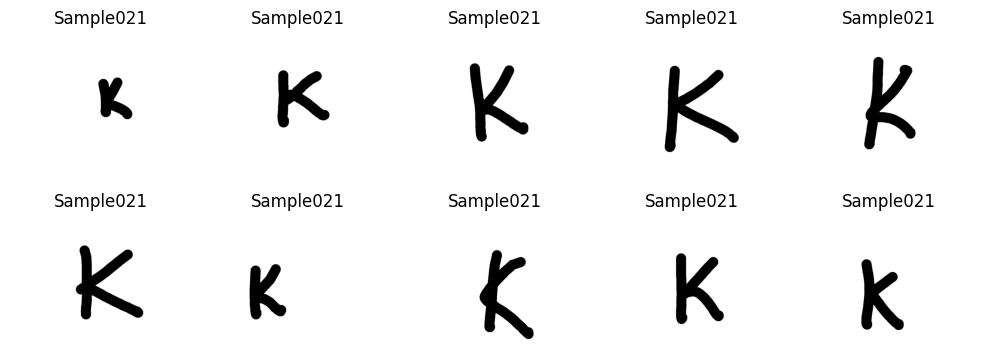

In [5]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, path in zip(axes.ravel(), png_files[:10]):
    img = Image.open(path).convert("L")
    ax.imshow(img, cmap="gray")
    ax.set_title(path.parent.name)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. Preprocessing



In [6]:
IMG_SIZE = 28

X = []
y = []

for class_index, class_dir in enumerate(sample_dirs):
    image_files = sorted(class_dir.glob("*.png"))

    for image_path in image_files:
        img = Image.open(image_path).convert("L")
        img = img.resize((IMG_SIZE, IMG_SIZE))
        arr = np.asarray(img, dtype=np.float32) / 255.0

        X.append(arr.flatten())
        y.append(class_index)

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int64)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Number of classes:", len(np.unique(y)))
print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

X shape: (3410, 784)
y shape: (3410,)
Number of classes: 62
Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [7]:
label_names = class_names[:len(np.unique(y))]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (2182, 784)
Validation: (546, 784)
Testing: (682, 784)


## 6. Model A — Multiclass Perceptron Learning Algorithm (PLA)


In [8]:
class MulticlassPerceptron:
    def __init__(self, n_classes, n_features, learning_rate=0.01, epochs=15):
        self.n_classes = n_classes
        self.n_features = n_features
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.W = np.zeros((n_classes, n_features), dtype=np.float32)
        self.b = np.zeros(n_classes, dtype=np.float32)
        self.error_history = []

    def predict(self, X):
        scores = X @ self.W.T + self.b
        return np.argmax(scores, axis=1)

    def decision_function(self, X):
        return X @ self.W.T + self.b

    def fit(self, X, y):
        for epoch in range(self.epochs):
            errors = 0
            indices = np.random.permutation(len(X))

            for i in indices:
                scores = X[i] @ self.W.T + self.b
                pred = np.argmax(scores)

                if pred != y[i]:
                    self.W[y[i]] += self.learning_rate * X[i]
                    self.b[y[i]] += self.learning_rate

                    self.W[pred] -= self.learning_rate * X[i]
                    self.b[pred] -= self.learning_rate

                    errors += 1

            error_rate = errors / len(X)
            self.error_history.append(error_rate)

            print(f"Epoch {epoch+1:2d}/{self.epochs} - error rate: {error_rate:.4f}")

        return self

In [9]:
pla = MulticlassPerceptron(
    n_classes=len(label_names),
    n_features=X_train.shape[1],
    learning_rate=0.01,
    epochs=15
)

pla.fit(X_train, y_train)

pla_pred = pla.predict(X_test)

pla_accuracy = accuracy_score(y_test, pla_pred)
pla_precision = precision_score(y_test, pla_pred, average="macro", zero_division=0)
pla_recall = recall_score(y_test, pla_pred, average="macro", zero_division=0)
pla_f1 = f1_score(y_test, pla_pred, average="macro", zero_division=0)

print("\nPLA Results")
print("Accuracy :", round(pla_accuracy, 4))
print("Precision:", round(pla_precision, 4))
print("Recall   :", round(pla_recall, 4))
print("F1-score :", round(pla_f1, 4))

Epoch  1/15 - error rate: 0.9803
Epoch  2/15 - error rate: 0.9583
Epoch  3/15 - error rate: 0.9248
Epoch  4/15 - error rate: 0.9047
Epoch  5/15 - error rate: 0.8932
Epoch  6/15 - error rate: 0.8845
Epoch  7/15 - error rate: 0.8639
Epoch  8/15 - error rate: 0.8515
Epoch  9/15 - error rate: 0.8318
Epoch 10/15 - error rate: 0.8185
Epoch 11/15 - error rate: 0.8135
Epoch 12/15 - error rate: 0.8194
Epoch 13/15 - error rate: 0.8176
Epoch 14/15 - error rate: 0.8126
Epoch 15/15 - error rate: 0.7832

PLA Results
Accuracy : 0.1422
Precision: 0.2574
Recall   : 0.1422
F1-score : 0.1307


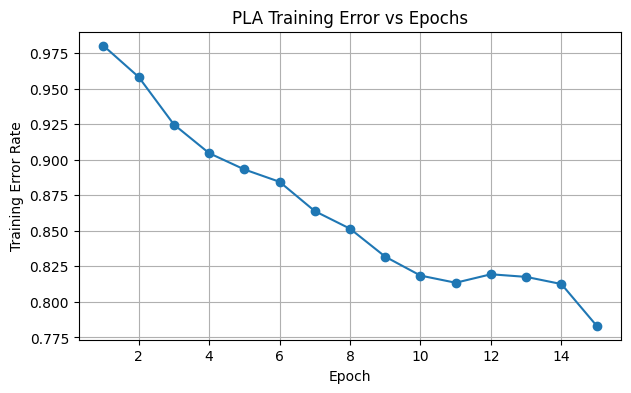

In [10]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, len(pla.error_history) + 1), pla.error_history, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Training Error Rate")
plt.title("PLA Training Error vs Epochs")
plt.grid(True)
plt.show()

## 7. Model B — Multilayer Perceptron (MLP)


In [33]:
def build_mlp(hidden_layers=(128,), activation="relu", optimizer_name="adam",
              learning_rate=0.001, loss_function="sparse_categorical_crossentropy"):

    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))

    for units in hidden_layers:
        model.add(Dense(units, activation=activation))

    model.add(Dense(len(label_names), activation="softmax"))

    if optimizer_name.lower() in ["gd", "sgd"]:
      optimizer = SGD(learning_rate=learning_rate)
    else:
      optimizer = Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss=loss_function,
        metrics=["accuracy"]
    )

    return model

In [34]:
# Cost function comparison

from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train, num_classes=len(label_names))
y_val_cat = to_categorical(y_val, num_classes=len(label_names))

loss_results = []

for loss_name in ["categorical_crossentropy", "mse"]:

    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(128, activation="tanh"),
        Dense(len(label_names), activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss=loss_name,
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train, y_train_cat,
        validation_data=(X_val, y_val_cat),
        epochs=10,
        batch_size=32,
        verbose=0
    )

    loss_results.append({
        "Cost Function": loss_name,
        "Best Validation Accuracy": max(history.history["val_accuracy"])
    })

loss_df = pd.DataFrame(loss_results)

print("Cost Function Comparison")
display(loss_df)

Cost Function Comparison


,Cost Function,Best Validation Accuracy
0,categorical_crossentropy,0.133700
1,mse,0.106227


## 8. Hyperparameter Tuning


In [35]:
configs = [
    {"hidden_layers": (64,), "activation": "relu", "optimizer": "sgd", "learning_rate": 0.01, "batch_size": 32},
    {"hidden_layers": (128,), "activation": "relu", "optimizer": "adam", "learning_rate": 0.001, "batch_size": 32},
    {"hidden_layers": (128,), "activation": "tanh", "optimizer": "adam", "learning_rate": 0.001, "batch_size": 32},
    {"hidden_layers": (128,), "activation": "relu", "optimizer": "adam", "learning_rate": 0.0005, "batch_size": 64},
    {"hidden_layers": (128, 64), "activation": "relu", "optimizer": "adam", "learning_rate": 0.001, "batch_size": 32},
    {"hidden_layers": (128, 64), "activation": "tanh", "optimizer": "adam", "learning_rate": 0.001, "batch_size": 32},
        {"hidden_layers": (128,), "activation": "tanh", "optimizer": "sgd", "learning_rate": 0.001, "batch_size": len(X_train)}
]

tuning_results = []

for i, cfg in enumerate(configs, start=1):
    print(f"\nConfiguration {i}/{len(configs)}")
    print(cfg)

    model = build_mlp(
        hidden_layers=cfg["hidden_layers"],
        activation=cfg["activation"],
        optimizer_name=cfg["optimizer"],
        learning_rate=cfg["learning_rate"]
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=12,
        batch_size=cfg["batch_size"],
        verbose=0
    )

    best_val_acc = max(history.history["val_accuracy"])
    final_val_acc = history.history["val_accuracy"][-1]

    tuning_results.append({
        **cfg,
        "best_validation_accuracy": best_val_acc,
        "final_validation_accuracy": final_val_acc
    })

    print("Best validation accuracy:", round(best_val_acc, 4))

tuning_df = pd.DataFrame(tuning_results)
tuning_df = tuning_df.sort_values("best_validation_accuracy", ascending=False).reset_index(drop=True)
tuning_df


Configuration 1/7
{'hidden_layers': (64,), 'activation': 'relu', 'optimizer': 'sgd', 'learning_rate': 0.01, 'batch_size': 32}
Best validation accuracy: 0.033

Configuration 2/7
{'hidden_layers': (128,), 'activation': 'relu', 'optimizer': 'adam', 'learning_rate': 0.001, 'batch_size': 32}
Best validation accuracy: 0.0165

Configuration 3/7
{'hidden_layers': (128,), 'activation': 'tanh', 'optimizer': 'adam', 'learning_rate': 0.001, 'batch_size': 32}
Best validation accuracy: 0.1172

Configuration 4/7
{'hidden_layers': (128,), 'activation': 'relu', 'optimizer': 'adam', 'learning_rate': 0.0005, 'batch_size': 64}
Best validation accuracy: 0.0623

Configuration 5/7
{'hidden_layers': (128, 64), 'activation': 'relu', 'optimizer': 'adam', 'learning_rate': 0.001, 'batch_size': 32}
Best validation accuracy: 0.0568

Configuration 6/7
{'hidden_layers': (128, 64), 'activation': 'tanh', 'optimizer': 'adam', 'learning_rate': 0.001, 'batch_size': 32}
Best validation accuracy: 0.1136

Configuration 7/7


,hidden_layers,activation,optimizer,learning_rate,batch_size,best_validation_accuracy,final_validation_accuracy
0,"(128,)",tanh,adam,0.0010,32,0.117216,0.117216
1,"(128, 64)",tanh,adam,0.0010,32,0.113553,0.113553
2,"(128,)",relu,adam,0.0005,64,0.062271,0.062271
3,"(128, 64)",relu,adam,0.0010,32,0.056777,0.056777
4,"(64,)",relu,sgd,0.0100,32,0.032967,0.031136
5,"(128,)",relu,adam,0.0010,32,0.016484,0.016484
6,"(128,)",tanh,sgd,0.0010,2182,0.009158,0.007326


## 9. Select the Best MLP Configuration



In [36]:
best_cfg = tuning_df.iloc[0].to_dict()

print("Selected configuration:")
print("Hidden layers :", best_cfg["hidden_layers"])
print("Activation    :", best_cfg["activation"])
print("Optimizer     :", best_cfg["optimizer"])
print("Learning rate :", best_cfg["learning_rate"])
print("Batch size    :", int(best_cfg["batch_size"]))
print("Best val acc  :", round(best_cfg["best_validation_accuracy"], 4))

Selected configuration:
Hidden layers : (128,)
Activation    : tanh
Optimizer     : adam
Learning rate : 0.001
Batch size    : 32
Best val acc  : 0.1172


## 10. Train the Final Tuned MLP



In [37]:
final_mlp = build_mlp(
    hidden_layers=tuple(best_cfg["hidden_layers"]),
    activation=best_cfg["activation"],
    optimizer_name=best_cfg["optimizer"],
    learning_rate=float(best_cfg["learning_rate"])
)

final_history = final_mlp.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=25,
    batch_size=int(best_cfg["batch_size"]),
    verbose=1
)

Epoch 1/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.0165 - loss: 4.2662 - val_accuracy: 0.0183 - val_loss: 4.1372
Epoch 2/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0151 - loss: 4.1664 - val_accuracy: 0.0256 - val_loss: 4.1020
Epoch 3/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0247 - loss: 4.1258 - val_accuracy: 0.0458 - val_loss: 4.0706
Epoch 4/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0325 - loss: 4.0658 - val_accuracy: 0.0495 - val_loss: 4.0078
Epoch 5/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0518 - loss: 3.9878 - val_accuracy: 0.0604 - val_loss: 3.9264
Epoch 6/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0701 - loss: 3.9043 - val_accuracy: 0.0696 - val_loss: 3.8496
Epoch 7/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0944 - loss: 3.8183 - val_accuracy: 0.1026 - val_loss: 3.7653
Epoch 8/25
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1091 - loss: 3.7310 - val_accuracy: 0.1245 - val_loss

In [38]:
mlp_prob = final_mlp.predict(X_test, verbose=0)
mlp_pred = np.argmax(mlp_prob, axis=1)

mlp_accuracy = accuracy_score(y_test, mlp_pred)
mlp_precision = precision_score(y_test, mlp_pred, average="macro", zero_division=0)
mlp_recall = recall_score(y_test, mlp_pred, average="macro", zero_division=0)
mlp_f1 = f1_score(y_test, mlp_pred, average="macro", zero_division=0)

print("\nTuned MLP Results")
print("Accuracy :", round(mlp_accuracy, 4))
print("Precision:", round(mlp_precision, 4))
print("Recall   :", round(mlp_recall, 4))
print("F1-score :", round(mlp_f1, 4))


Tuned MLP Results
Accuracy : 0.2331
Precision: 0.2423
Recall   : 0.2331
F1-score : 0.2074


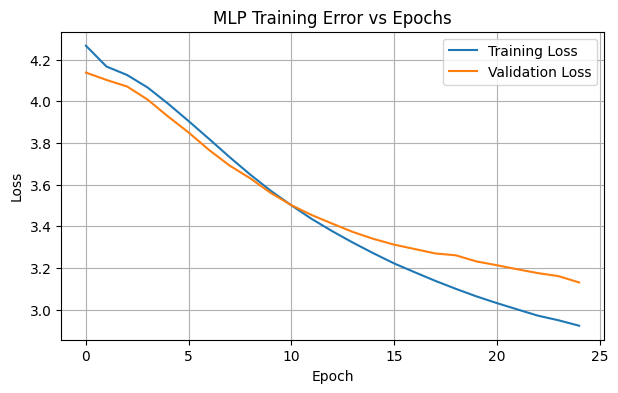

In [39]:
plt.figure(figsize=(7, 4))
plt.plot(final_history.history["loss"], label="Training Loss")
plt.plot(final_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Training Error vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

## 11. Confusion Matrices

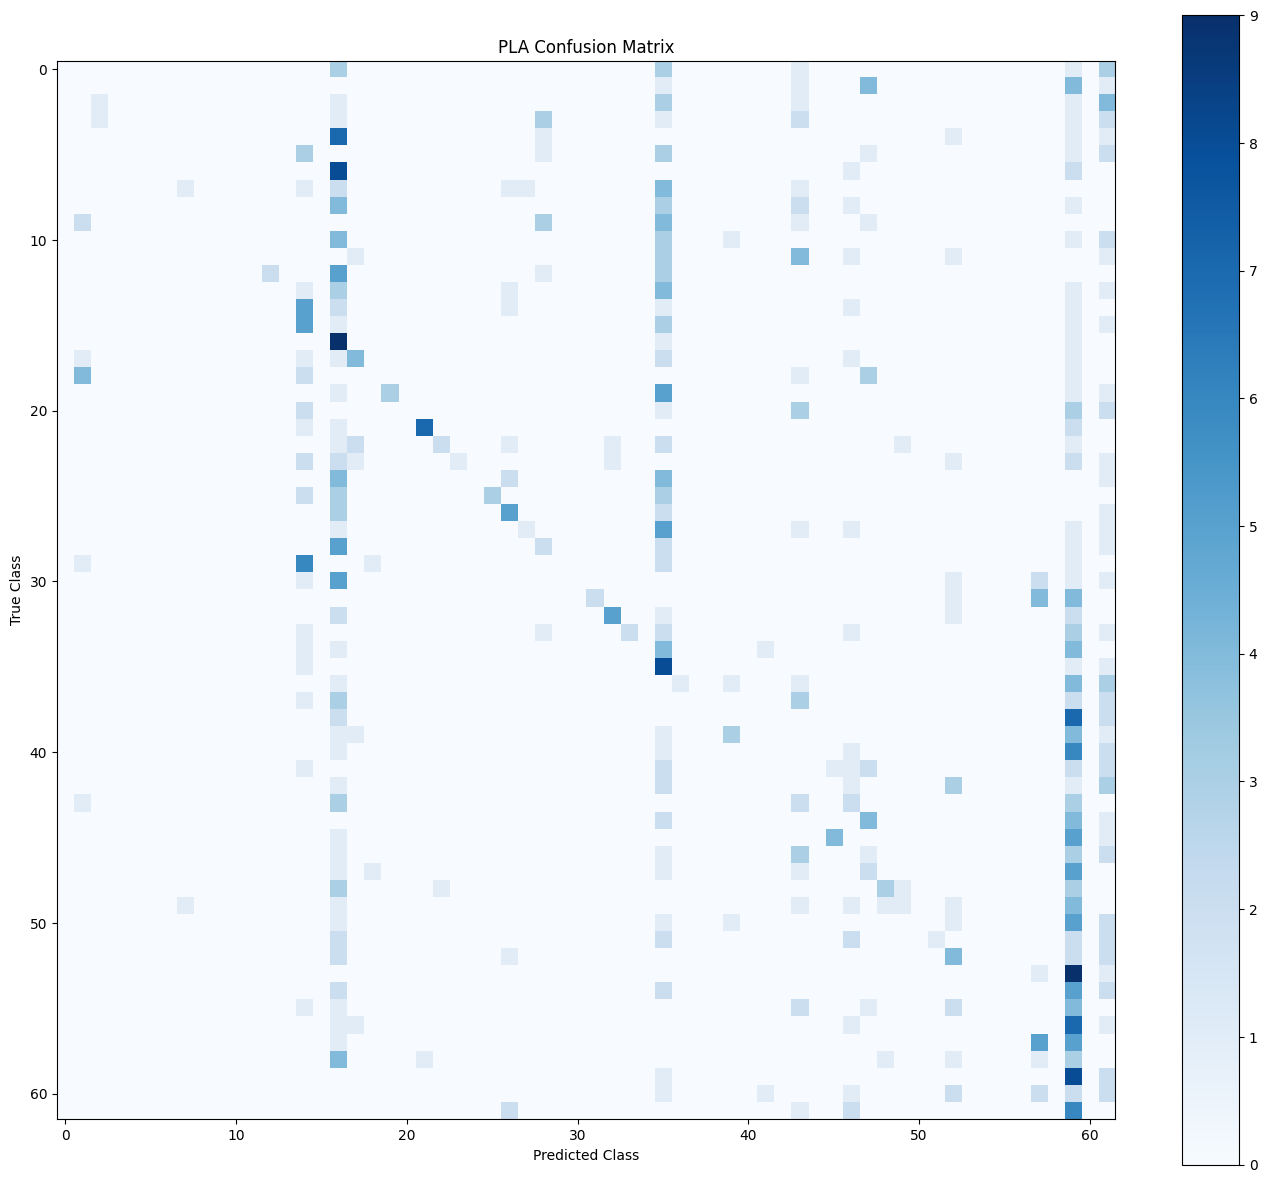

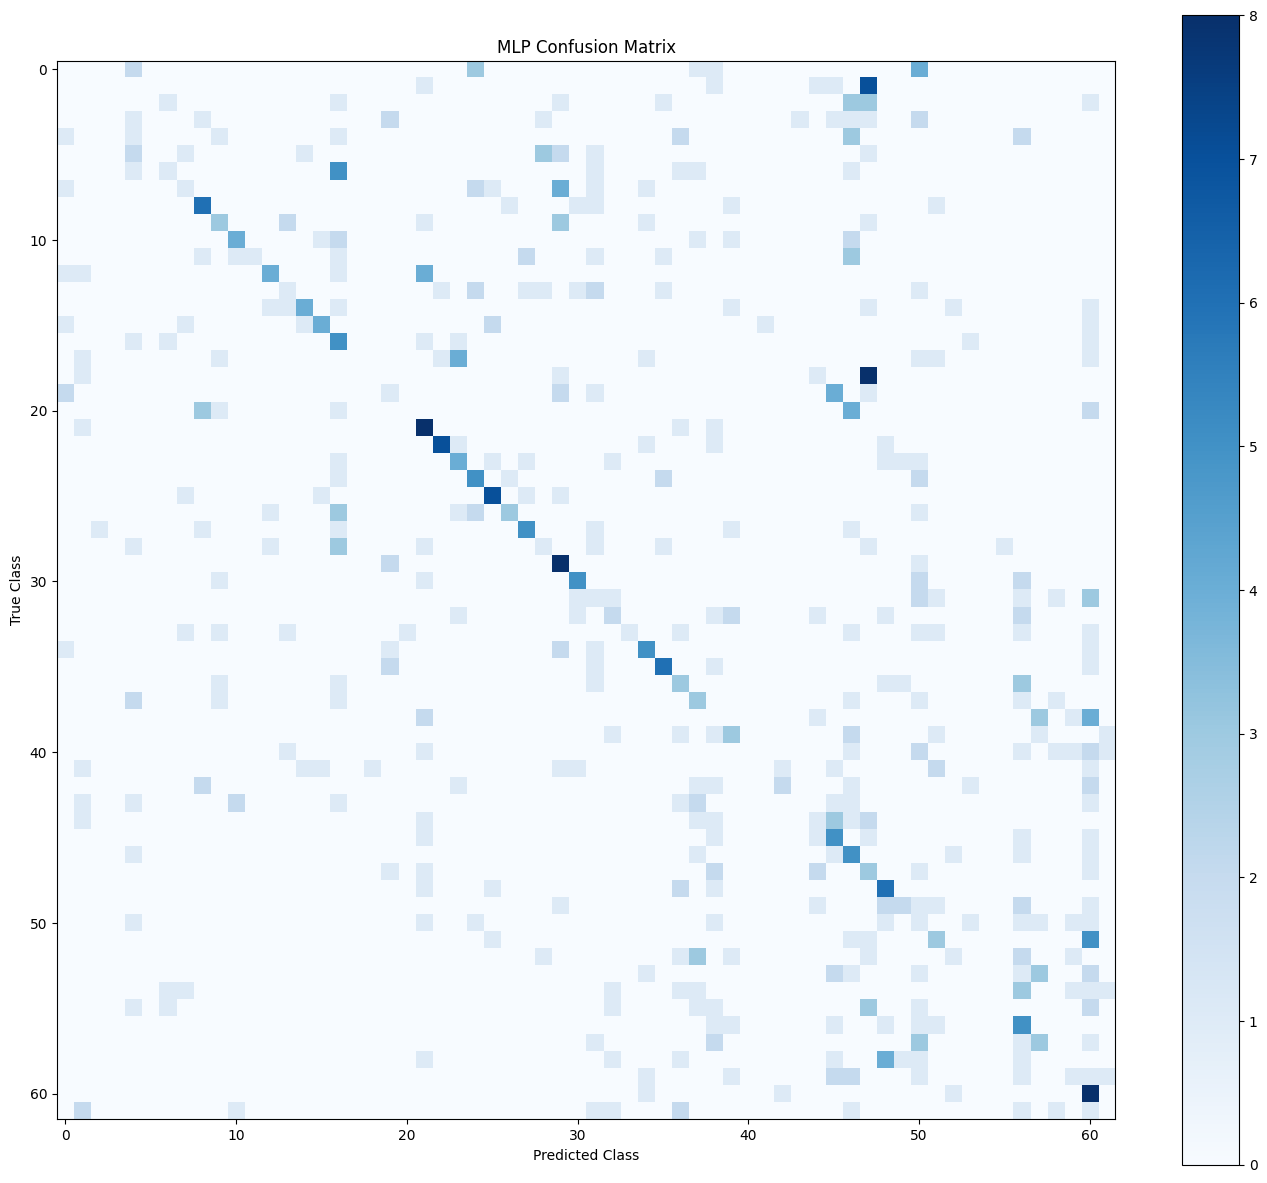

In [40]:
cm_pla = confusion_matrix(y_test, pla_pred)
cm_mlp = confusion_matrix(y_test, mlp_pred)

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm_pla, interpolation="nearest", cmap="Blues")
ax.set_title("PLA Confusion Matrix")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm_mlp, interpolation="nearest", cmap="Blues")
ax.set_title("MLP Confusion Matrix")
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 12. ROC Curves — Micro and Macro Average



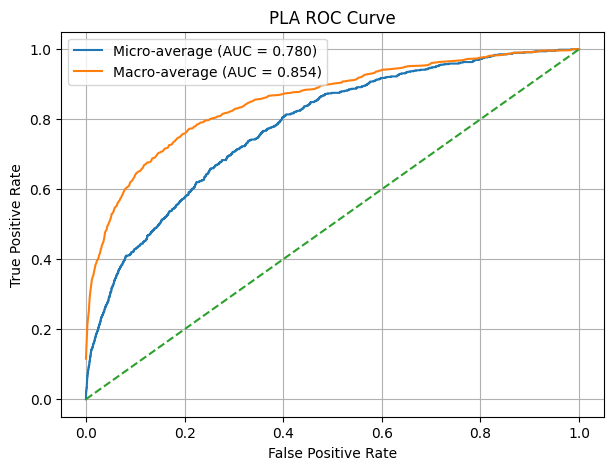

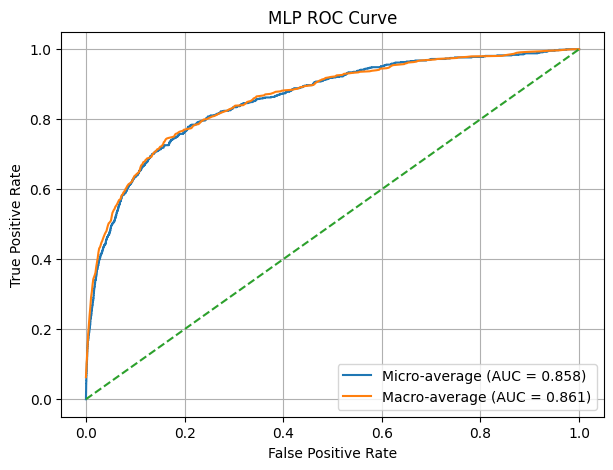

PLA Micro AUC: 0.7797
PLA Macro AUC: 0.8543
MLP Micro AUC: 0.8577
MLP Macro AUC: 0.8609


In [41]:
y_test_bin = label_binarize(y_test, classes=np.arange(len(label_names)))

pla_scores = pla.decision_function(X_test)

# Convert PLA scores to a probability-like scale for ROC calculation.
pla_exp = np.exp(pla_scores - np.max(pla_scores, axis=1, keepdims=True))
pla_prob = pla_exp / pla_exp.sum(axis=1, keepdims=True)

def plot_micro_macro_roc(y_true_bin, scores, title):
    fpr = {}
    tpr = {}
    roc_auc = {}

    n_classes = y_true_bin.shape[1]

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], scores[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), scores.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    mean_tpr /= n_classes
    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    plt.figure(figsize=(7, 5))
    plt.plot(fpr["micro"], tpr["micro"],
             label=f"Micro-average (AUC = {roc_auc['micro']:.3f})")
    plt.plot(fpr["macro"], tpr["macro"],
             label=f"Macro-average (AUC = {roc_auc['macro']:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

    return roc_auc

pla_roc_auc = plot_micro_macro_roc(
    y_test_bin, pla_prob, "PLA ROC Curve"
)

mlp_roc_auc = plot_micro_macro_roc(
    y_test_bin, mlp_prob, "MLP ROC Curve"
)

print("PLA Micro AUC:", round(pla_roc_auc["micro"], 4))
print("PLA Macro AUC:", round(pla_roc_auc["macro"], 4))
print("MLP Micro AUC:", round(mlp_roc_auc["micro"], 4))
print("MLP Macro AUC:", round(mlp_roc_auc["macro"], 4))

## 13. Final A/B Comparison

In [42]:
comparison = pd.DataFrame({
    "Model": ["PLA", "Tuned MLP"],
    "Accuracy": [pla_accuracy, mlp_accuracy],
    "Precision": [pla_precision, mlp_precision],
    "Recall": [pla_recall, mlp_recall],
    "F1-score": [pla_f1, mlp_f1]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-score
0,PLA,0.1422,0.2574,0.1422,0.1307
1,Tuned MLP,0.2331,0.2423,0.2331,0.2074


## 14. Observation

In [43]:
print("PLA Accuracy :", round(pla_accuracy, 4))
print("MLP Accuracy :", round(mlp_accuracy, 4))
print("PLA F1-score :", round(pla_f1, 4))
print("MLP F1-score :", round(mlp_f1, 4))
print()
print("Best MLP configuration:")
print(best_cfg)

PLA Accuracy : 0.1422
MLP Accuracy : 0.2331
PLA F1-score : 0.1307
MLP F1-score : 0.2074

Best MLP configuration:
{'hidden_layers': (128,), 'activation': 'tanh', 'optimizer': 'adam', 'learning_rate': 0.001, 'batch_size': 32, 'best_validation_accuracy': 0.11721611768007278, 'final_validation_accuracy': 0.11721611768007278}
